# 06 — EDA Blocco 2: Profilo demografico delle vittime

**Fase PACE**: Analyze  
**Obiettivo**: analizzare il profilo demografico delle vittime (sesso, età, etnia) 
a livello aggregato, per tipo di crimine e per area LAPD. Focus specifico 
sulle vittime anziane (65+).

**Input**: `data/processed/crimes_features.parquet`

**Domande a cui rispondiamo**:
- Q2.1 — Distribuzione vittime per sesso, età, etnia (integrato per area LAPD)
- Q2.2 — Profilo vittime incrociato con tipologie di crimine
- Q2.3 — Focus vittime anziane (65+): tipologie di reato e aree

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_row', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_info_columns', 200)

df = pd.read_parquet('../../data/processed/crimes_features.parquet')

df.head()

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


## 2. Q2.1 — Distribuzione vittime per sesso

Analizziamo la distribuzione demografica delle vittime sull'intero dataset. 
Per ciascuna dimensione (sesso, età, etnia) produciamo prima una visualizzazione 
aggregata, poi integriamo per area LAPD per identificare differenze territoriali.

In [2]:
q21_df = df[['AREA NAME', 'Vict Age', 'Vict Sex', 'Vict Descent', 'age_group']].copy()

sex_dist_df = (
    q21_df
    .groupby('Vict Sex', as_index = False)
    .agg(count = ('Vict Sex', 'count'))
)

print(sex_dist_df.head())

  Vict Sex    count
0        F  1230565
1        M  1359841
2        X   489018


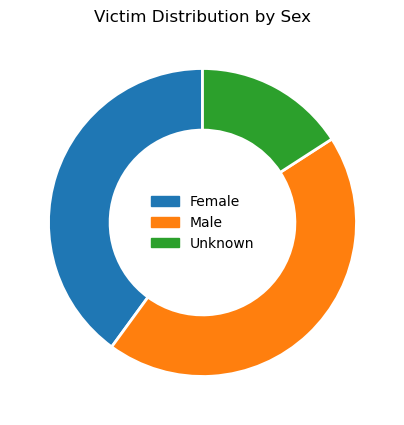

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))

wedges, texts = ax.pie(
    x=sex_dist_df['count'],
    wedgeprops={'width': 0.4, 'linewidth': 2, 'edgecolor': 'white'},
    startangle=90
)

# Legenda interna con barra colorata - etichetta
sex_labels = {
    'F': 'Female',
    'M': 'Male',
    'X': 'Unknown'
}

labels = [sex_labels.get(s, s) for s in sex_dist_df['Vict Sex'].tolist()]
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color=wedges[i].get_facecolor(), label=labels[i])
    for i in range(len(wedges))
]
ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    fontsize=10
)

ax.set_title('Victim Distribution by Sex')

plt.savefig('../../outputs/06_eda_block2/08_donut_victim_sex.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q2.1 — Distribuzione per sesso

- **Maschi** (44.2%, 1.359.841): categoria più rappresentata, ma con un margine 
  contenuto rispetto alle femmine.
- **Femmine** (40.0%, 1.230.565): gap di soli 4 punti percentuali rispetto ai 
  maschi. Distribuzione più equilibrata di quanto ci si potrebbe aspettare, 
  probabilmente perché il dataset include tutti i tipi di crimine, inclusi 
  quelli domestici dove le donne sono sovrarappresentate come vittime.
- **Sconosciuto** (15.9%, 489.018): quota significativa, composta principalmente 
  da crimini senza vittima diretta identificabile (furti di veicoli, vandalismi) 
  dove il sesso non viene registrato.

**Nota**: la sovrarappresentazione maschile tipica della letteratura criminologica 
(violenza pubblica) risulta attenuata in questo dataset aggregato. La separazione 
per tipo di crimine nel Blocco 3 (reati domestici) mostrerà con più chiarezza 
le differenze di genere per categoria specifica.

### Q2.1 — Distribuzione per fascia di età

Analizziamo la distribuzione delle vittime per fascia di età utilizzando 
la colonna `age_group` creata in fase di feature engineering.
Le fasce sono: Child (0-12), Adolescent (13-17), Young Adult (18-34), 
Adult (35-64), Senior (65+).

**Nota**: 632.399 record hanno `age_group` nullo (vittime con età sconosciuta, 
codificata come 0 nel dataset originale). Questi record vengono esclusi 
automaticamente dal groupby.

In [4]:
age_dist_df = (
    q21_df
    .groupby('age_group', as_index = False, observed = True)
    .agg(count = ('age_group', 'count'))
)

print(age_dist_df.head())

     age_group    count
0        Child    44288
1   Adolescent    84156
2  Young Adult   991025
3        Adult  1158297
4       Senior   169266


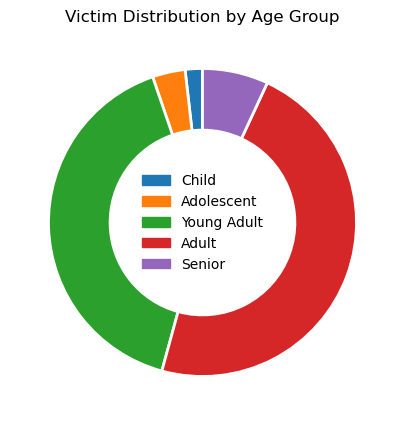

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))

wedges, texts = ax.pie(
    x=age_dist_df['count'],
    wedgeprops={'width': 0.4, 'linewidth': 2, 'edgecolor': 'white'},
    startangle=90
)

labels = age_dist_df['age_group'].tolist()
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color=wedges[i].get_facecolor(), label=labels[i])
    for i in range(len(wedges))
]

ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    fontsize=10
)

ax.set_title('Victim Distribution by Age Group')

plt.savefig('../../outputs/06_eda_block2/09_donut_victim_age.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q2.1 — Distribuzione per fascia di età

- **Adult (35-64)**: fascia più colpita con 1.158.297 vittime (47.4% dei casi 
  con età nota), seguita da Young Adult (18-34) con 991.025 (40.5%). Insieme 
  rappresentano quasi il 90% delle vittime con età registrata.

- **Senior (65+)**: 169.266 vittime (6.9%). Pur non essendo il bersaglio 
  principale, gli anziani rappresentano una quota significativa che merita 
  attenzione specifica (Q2.3).

- **Adolescent (13-17)**: 84.156 vittime (3.4%).

- **Child (0-12)**: fascia meno colpita con 44.288 vittime (1.8% del totale).

**Nota metodologica**: la bassa quota dei minori (Child + Adolescent = 5.2%) 
va interpretata con cautela per due ragioni. Prima: il dataset include tutti 
i tipi di crimine, molti dei quali non coinvolgono minori per definizione 
(furti di veicoli, frodi, vandalismi). Seconda: gli abusi su minori sono 
storicamente i crimini più sottodenunciati — spesso scoperti anni dopo o mai 
denunciati — il che introduce un bias di selezione significativo. 
L'analisi specifica del Blocco 3 (abusi domestici e sicurezza minori) 
approfondirà questo tema isolando i crimini rilevanti.

- **Valori NaN**: 632.399 record esclusi dall'analisi (vittime con età 
  sconosciuta, codificata come 0 nel dataset originale).

### Q2.1 — Distribuzione per etnia

Analizziamo la distribuzione delle vittime per etnia utilizzando la colonna 
`Vict Descent`. Il dataset LAPD usa codici a lettera singola per identificare 
l'origine etnica delle vittime (es. H = Hispanic, B = Black, W = White, ecc.).

In [6]:
desc_dist_df = (
    q21_df
    .groupby('Vict Descent', as_index = False, observed = True)
    .agg(count = ('Vict Descent', 'count'))
)

print(desc_dist_df.head(20))

   Vict Descent    count
0             -        5
1             A    71288
2             B   464720
3             C     5695
4             D      115
5             F     7370
6             G      152
7             H  1006783
8             I     1960
9             J     2000
10            K    14335
11            L       97
12            O   276964
13            P      624
14            S       89
15            U      408
16            V     1401
17            W   704718
18            X   519983
19            Z      717


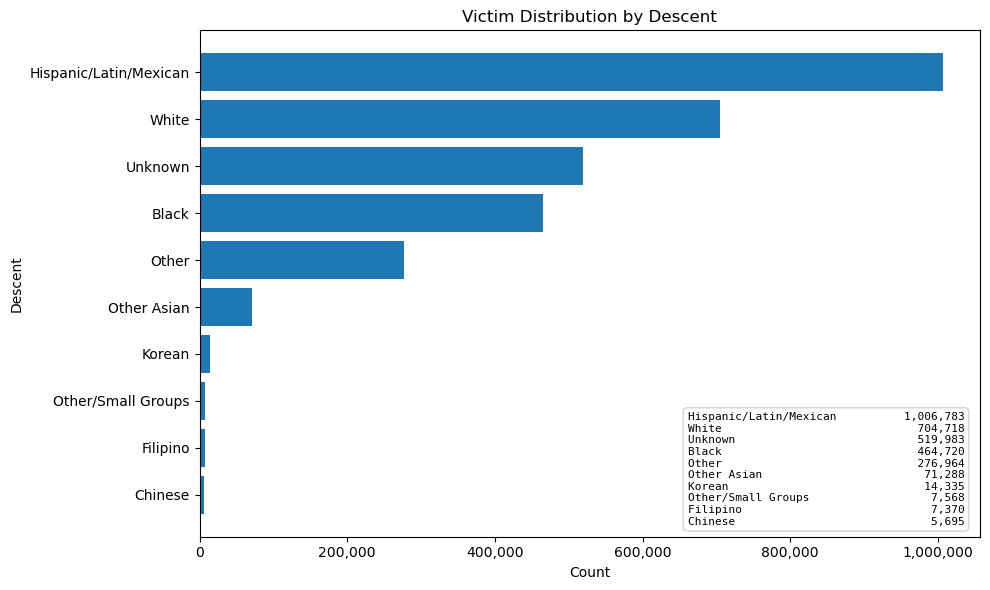

In [7]:
descent_labels = {
    'A': 'Other Asian',
    'B': 'Black',
    'C': 'Chinese',
    'D': 'Cambodian',
    'F': 'Filipino',
    'G': 'Guamanian',
    'H': 'Hispanic/Latin/Mexican',
    'I': 'American Indian/Alaska Native',
    'J': 'Japanese',
    'K': 'Korean',
    'L': 'Laotian',
    'O': 'Other',
    'P': 'Pacific Islander',
    'S': 'Samoan',
    'U': 'Hawaiian',
    'V': 'Vietnamese',
    'W': 'White',
    'X': 'Unknown',
    'Z': 'Asian Indian',
    '-': 'Unknown'
}

# Soglia e raggruppamento
threshold = 2500

desc_dist_df['label'] = desc_dist_df['Vict Descent'].map(descent_labels)

desc_dist_df['label_grouped'] = desc_dist_df.apply(
    lambda row: 'Other/Small Groups' if row['count'] < threshold else row['label'],
    axis=1
)

# Aggrega le righe raggruppate
desc_grouped_df = (
    desc_dist_df
    .groupby('label_grouped', as_index=False)
    .agg(count=('count', 'sum'))
    .sort_values('count', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    y=desc_grouped_df['label_grouped'],
    width=desc_grouped_df['count']
)

# Legenda in basso a destra con nome - valore
legend_labels = [
    f"{row['label_grouped']}: {int(row['count']):,}"
    for _, row in desc_grouped_df.sort_values('count', ascending=False).iterrows()
]
legend_text = '\n'.join([
    f"{row['label_grouped']:<30} {int(row['count']):>10,}"
    for _, row in desc_grouped_df.sort_values('count', ascending=False).iterrows()
])

ax.text(
    0.98, 0.02, legend_text,
    transform=ax.transAxes,
    fontsize=8,
    va='bottom', ha='right',
    fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='lightgrey')
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Victim Distribution by Descent')
ax.set_xlabel('Count')
ax.set_ylabel('Descent')

plt.tight_layout()
plt.savefig('../../outputs/06_eda_block2/10_barh_victim_descent.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q2.1 — Distribuzione per etnia

- **Hispanic/Latin/Mexican** (1.006.783): la comunità ispanica è la categoria 
  più colpita in termini assoluti, rappresentando circa il 32.7% delle vittime 
  con etnia registrata. 

- **White** (704.718, 22.9%) e **Black** (464.720, 15.1%): seconda e terza 
  categoria più colpita.

- **Unknown** (519.983, 16.9%): quota significativa di vittime con etnia 
  non registrata.

- **Other** (276.964, 9.0%): categoria residuale che aggrega etnie non 
  classificabili nei codici LAPD.

- **Categorie minori**: Other Asian (71.288), Korean (14.335), Filipino (7.370), 
  Chinese (5.695) e altri gruppi aggregati in "Other/Small Groups" (7.568).

**Nota metodologica critica**: i valori assoluti non permettono conclusioni 
sulla sovra o sottorappresentazione delle singole etnie come vittime. 
Per un'analisi corretta sarebbe necessario confrontare questi dati con la 
composizione demografica della città di Los Angeles (dati Census/ACS), 
che non sono inclusi nel dataset LAPD. Questo confronto è stato identificato 
nelle limitazioni del progetto e richiederebbe l'integrazione con dati esterni.

**Fonte codici etnia**: LAPD Crime Data Dictionary, disponibile su 
data.lacity.org nella documentazione del dataset Crime Data from 2020 to Present.

## 3. Q2.2 — Profilo vittime per tipologia di crimine

Incrociamo il profilo demografico delle vittime con le tipologie di crimine. 
Obiettivo: capire se il profilo cambia significativamente a seconda del tipo 
di reato — chi viene colpito da crimini violenti rispetto a crimini contro 
la proprietà, e se esistono pattern demografici specifici per categoria.

Analizziamo separatamente:
- Distribuzione per sesso nelle due macro-categorie (Person vs Property)
- Distribuzione per fascia di età nelle due macro-categorie

In [8]:
q22_df = (
    df
    .groupby(['Vict Sex', 'age_group', 'crime_category'], as_index = False, observed=True)
    .agg(count = ('Vict Sex', 'count'))
)

q22_df = q22_df[q22_df['crime_category'] != 'other']
print(q22_df.head(50))

   Vict Sex    age_group crime_category   count
1         F        Child         person   23336
2         F        Child       property    1060
4         F   Adolescent         person   41717
5         F   Adolescent       property    4512
7         F  Young Adult         person  263270
8         F  Young Adult       property  252531
10        F        Adult         person  218596
11        F        Adult       property  311992
13        F       Senior         person   20653
14        F       Senior       property   59907
16        M        Child         person   16436
17        M        Child       property    2027
19        M   Adolescent         person   26823
20        M   Adolescent       property    6559
22        M  Young Adult         person  188271
23        M  Young Adult       property  264573
25        M        Adult         person  213625
26        M        Adult       property  396147
28        M       Senior         person   23676
29        M       Senior       property 

In [9]:
q22_property_df = q22_df [q22_df['crime_category'] == 'property'].copy()
q22_person_df = q22_df[q22_df['crime_category'] == 'person'].copy()

print(q22_property_df.head())
print("===============")
print(q22_person_df.head())

   Vict Sex    age_group crime_category   count
2         F        Child       property    1060
5         F   Adolescent       property    4512
8         F  Young Adult       property  252531
11        F        Adult       property  311992
14        F       Senior       property   59907
   Vict Sex    age_group crime_category   count
1         F        Child         person   23336
4         F   Adolescent         person   41717
7         F  Young Adult         person  263270
10        F        Adult         person  218596
13        F       Senior         person   20653


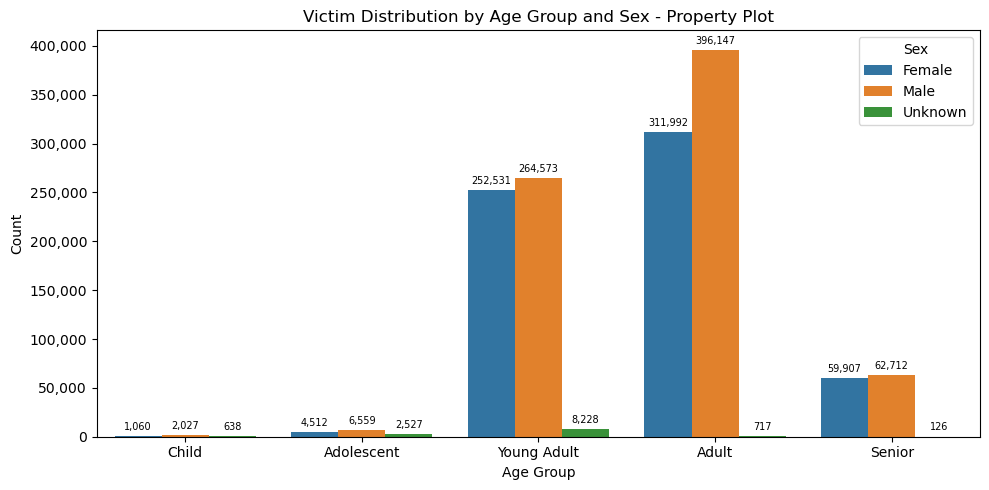

In [10]:
sex_labels = {'F': 'Female', 'M': 'Male', 'X': 'Unknown'}
q22_property_df['Vict Sex Label'] = q22_property_df['Vict Sex'].map(sex_labels)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=q22_property_df,
    x='age_group',
    y='count',
    hue='Vict Sex Label',
    order=['Child', 'Adolescent', 'Young Adult', 'Adult', 'Senior']
)

# Numeri sopra ogni barra
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{int(x):,}' if x > 0 else '', 
                 padding=3, fontsize=7)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Victim Distribution by Age Group and Sex - Property Plot')
ax.set_xlabel('Age Group')
ax.set_ylabel('Count')
ax.legend(title='Sex')

plt.tight_layout()
plt.savefig('../../outputs/06_eda_block2/11_barplot_victim_age_sex_property_plot.png', dpi=150, bbox_inches='tight')
plt.show()

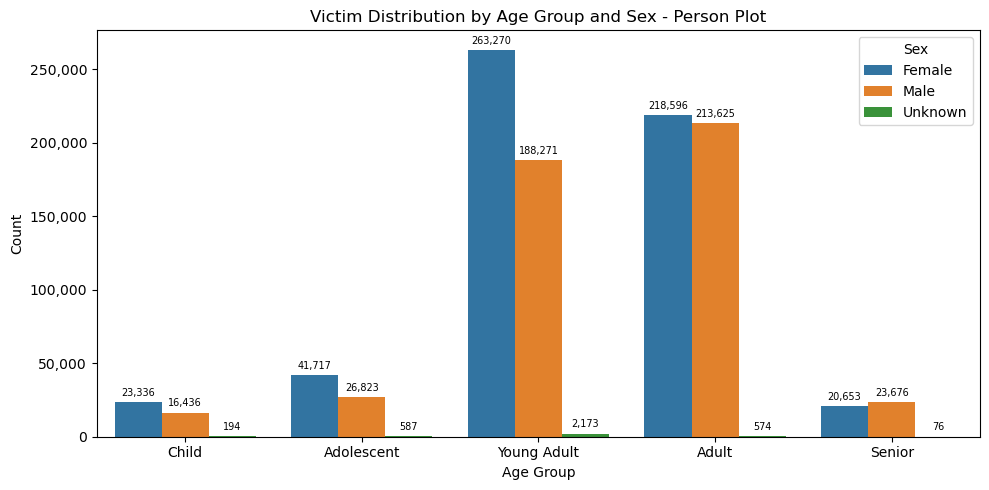

In [11]:
sex_labels = {'F': 'Female', 'M': 'Male', 'X': 'Unknown'}
q22_person_df['Vict Sex Label'] = q22_person_df['Vict Sex'].map(sex_labels)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=q22_person_df,
    x='age_group',
    y='count',
    hue='Vict Sex Label',
    order=['Child', 'Adolescent', 'Young Adult', 'Adult', 'Senior']
)

# Numeri sopra ogni barra
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{int(x):,}' if x > 0 else '', 
                 padding=3, fontsize=7)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Victim Distribution by Age Group and Sex - Person Plot')
ax.set_xlabel('Age Group')
ax.set_ylabel('Count')
ax.legend(title='Sex')

plt.tight_layout()
plt.savefig('../../outputs/06_eda_block2/12_barplot_victim_age_sex_person_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q2.2 — Profilo vittime per macro-categoria di crimine

**Crimini contro la proprietà (Property)**

- **Child e Adolescent quasi assenti**: i minori rappresentano una quota 
  trascurabile delle vittime di crimini contro la proprietà. Ha senso 
  strutturalmente: furti, scassi e vandalismi colpiscono tipicamente chi 
  possiede beni, e i minori raramente sono intestatari di proprietà.

- **Young Adult — quasi parità M/F** (264.573 M vs 252.531 F): nella fascia 
  18-34 il rischio di subire crimini contro la proprietà è distribuito 
  equamente tra i sessi.

- **Adult — prevalenza maschile marcata** (396.147 M vs 311.992 F): nella 
  fascia 35-64 emerge una differenza significativa, probabilmente legata 
  a una maggiore esposizione maschile in contesti lavorativi e di mobilità.

- **Senior — distribuzione equilibrata** (62.712 M vs 59.907 F): il gap 
  si riduce nuovamente nella fascia anziana.

**Crimini contro la persona (Person)**

- **Child — prevalenza femminile** (23.336 F vs 16.436 M): le bambine sono 
  colpite in misura significativamente maggiore dai crimini contro la persona. 
  Pattern coerente con la letteratura sugli abusi sessuali e la violenza 
  domestica che colpiscono le femmine in modo sproporzionato già nelle 
  fasce d'età più giovani.

- **Adolescent — gap F/M più marcato** (41.717 F vs 26.823 M): la differenza 
  si amplia nell'adolescenza, confermando il pattern. Questo dato sarà 
  approfondito nel Blocco 3 (abusi domestici e sicurezza minori).

- **Young Adult — ancora prevalenza femminile** (263.270 F vs 188.271 M): 
  la fascia 18-34 mostra il gap assoluto più alto in termini numerici.

- **Adult — quasi parità** (218.596 F vs 213.625 M): il divario si riduce 
  drasticamente nella fascia 35-64.

- **Senior — inversione, leggera prevalenza maschile** (23.676 M vs 20.653 F): 
  unica fascia dove i maschi superano le femmine nei crimini contro la persona. 
  Potrebbe riflettere una maggiore esposizione degli uomini anziani a crimini 
  di strada (rapine, aggressioni).

**Confronto tra le due categorie**

Il dato più significativo dell'intera analisi è la **inversione del pattern 
di genere** tra Property e Person: nei crimini contro la proprietà i maschi 
sono sistematicamente più colpiti nelle fasce adulte, mentre nei crimini 
contro la persona le femmine sono sovrarappresentate in tutte le fasce 
tranne i Senior. Questo suggerisce dinamiche molto diverse alla base dei 
due tipi di crimine, che il Blocco 3 esplorerà in dettaglio per i reati 
domestici.